<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/DL_COMPUTER_VISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Keras Sequential API Model : CIFAR-10/MNIST DATASET

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


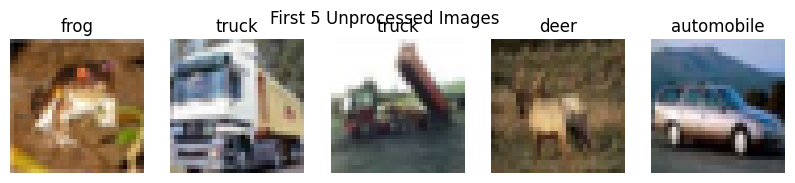

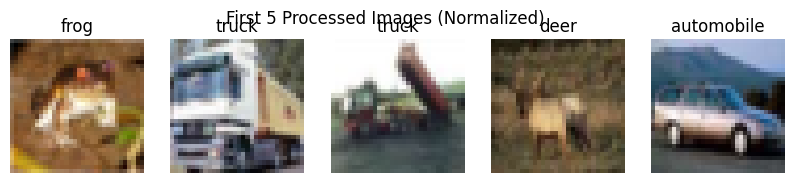

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.3333 - loss: 1.8027 - val_accuracy: 0.5385 - val_loss: 1.2790
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.5570 - loss: 1.2444 - val_accuracy: 0.6054 - val_loss: 1.1127
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6211 - loss: 1.0791 - val_accuracy: 0.6212 - val_loss: 1.0589
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6646 - loss: 0.9659 - val_accuracy: 0.6582 - val_loss: 0.9855
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6933 - loss: 0.8733 - val_accuracy: 0.6905 - val_loss: 0.8878
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7217 - loss: 0.8018 - val_accuracy: 0.6897 - val_loss: 0.8874
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7363 - loss: 0.7514 - val_accuracy: 0.6888 - val_loss: 0.8970
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7550 - loss: 0.6989 - val_accuracy: 

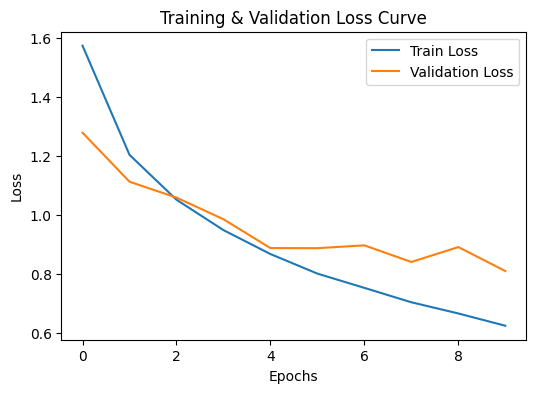

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


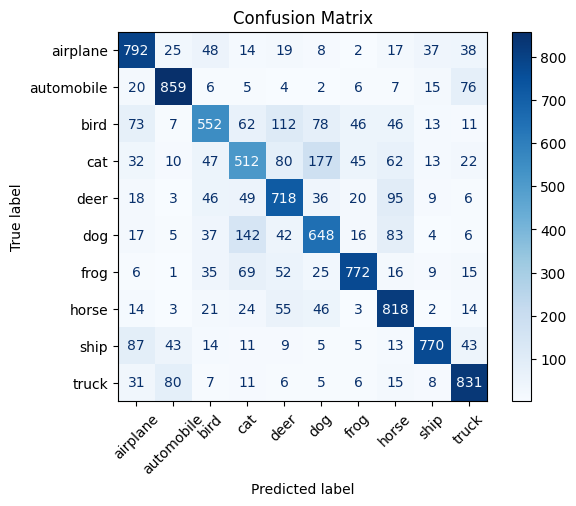

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

# 2. Display first 5 unprocessed images
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("First 5 Unprocessed Images")
plt.show()

# 3. Normalize (processed images)
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# 4. Display first 5 processed images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_norm[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("First 5 Processed Images (Normalized)")
plt.show()

# 5. Build Sequential CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')   # output layer
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train model
history = model.fit(x_train_norm, y_train,
                    epochs=10,
                    validation_data=(x_test_norm, y_test),
                    batch_size=64,
                    verbose=1)

# 7. Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training & Validation Loss Curve")
plt.show()

# 8. Predictions and Confusion Matrix
y_pred = np.argmax(model.predict(x_test_norm), axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# KERAS Functional API model

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


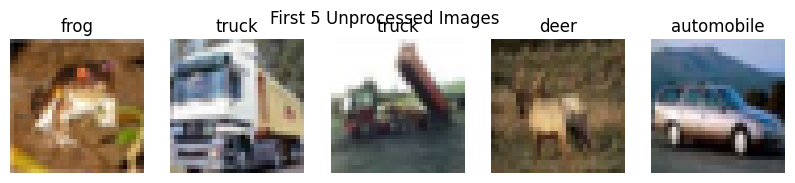

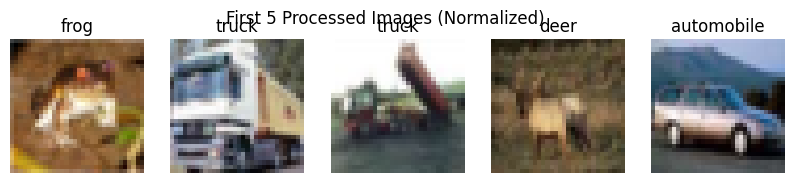

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2544 - loss: 2.0063 - val_accuracy: 0.4482 - val_loss: 1.5225
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5042 - loss: 1.3737 - val_accuracy: 0.5704 - val_loss: 1.2000
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5796 - loss: 1.1838 - val_accuracy: 0.6065 - val_loss: 1.1054
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6359 - loss: 1.0309 - val_accuracy: 0.6319 - val_loss: 1.0412
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6661 - loss: 0.9418 - val_accuracy: 0.6630 - val_loss: 0.9625
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7029 - loss: 0.8561 - val_accuracy: 0.6815 - val_loss: 0.9348
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7269 - loss: 0.7818 - val_accuracy: 0.6770 - val_loss: 0.9180
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7436 - loss: 0.7312 - val_accuracy: 0

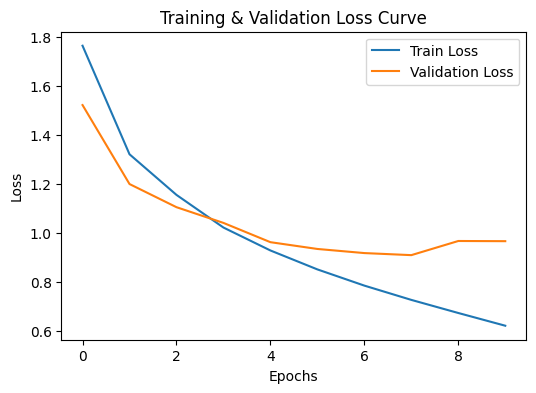

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


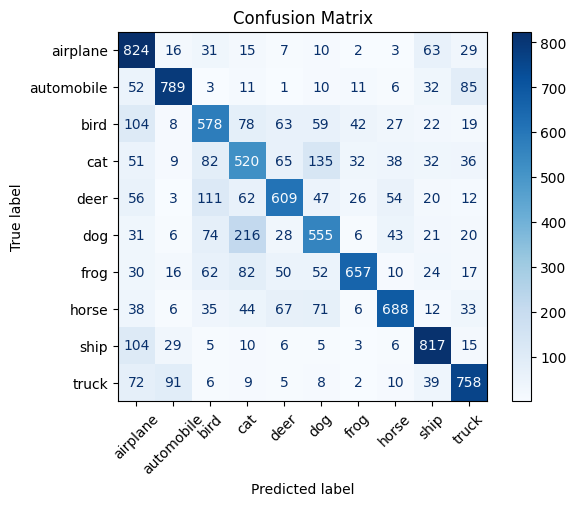

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

# 2. Display first 5 unprocessed images
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("First 5 Unprocessed Images")
plt.show()

# 3. Normalize (processed images)
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# 4. Display first 5 processed images
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train_norm[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("First 5 Processed Images (Normalized)")
plt.show()

# 5. Build Sequential CNN Model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')   # output layer
])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train model
history = model.fit(x_train_norm, y_train,
                    epochs=10,
                    validation_data=(x_test_norm, y_test),
                    batch_size=64,
                    verbose=1)

# 7. Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Training & Validation Loss Curve")
plt.show()

# 8. Predictions and Confusion Matrix
y_pred = np.argmax(model.predict(x_test_norm), axis=1)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()


# SOFTMAX REGRESSION WITH KERAS

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.1512 - loss: 1.5822 - val_accuracy: 0.5000 - val_loss: 0.9525
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5243 - loss: 0.8429 - val_accuracy: 0.6667 - val_loss: 0.6669
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5734 - loss: 0.6977 - val_accuracy: 0.8667 - val_loss: 0.5441
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7746 - loss: 0.5600 - val_accuracy: 0.8667 - val_loss: 0.4833
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7484 - loss: 0.5705 - val_accuracy: 0.8667 - val_loss: 0.4388
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7913 - loss: 0.4834 - val_accuracy: 0.8667 - val_loss: 0.4079
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8202 - loss: 0.4456 - val_accuracy: 0.8667 - val_loss: 0.3837
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8155 - loss: 0.4371 - val_accuracy: 0.8667 - val_loss: 0.3650
Epoch 

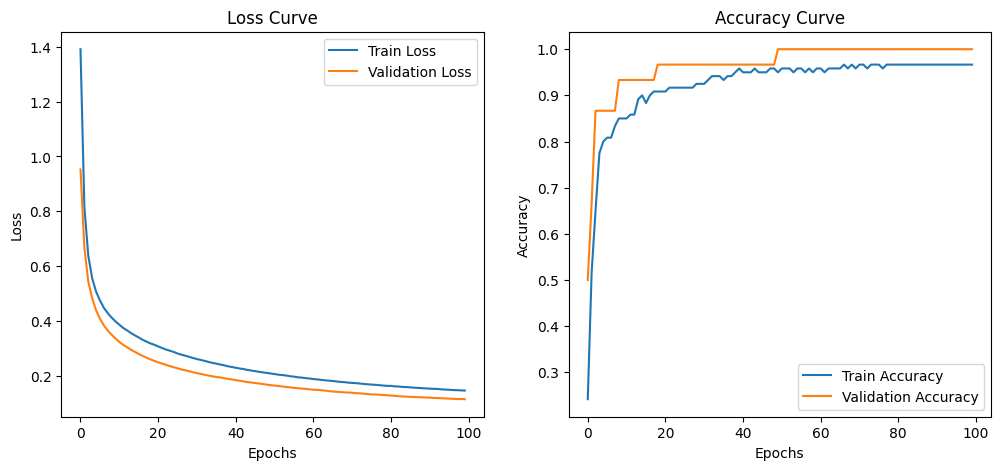

✅ Test Accuracy: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


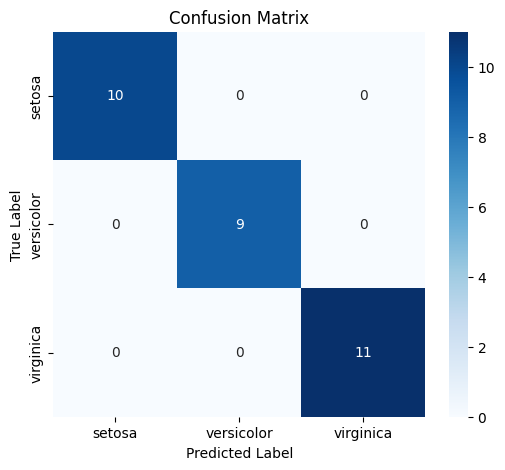


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Sample Predictions (True vs Predicted):
True: versicolor, Predicted: versicolor
True: setosa, Predicted: setosa
True: virginica, Predicted: virginica
True: versicolor, Predicted: versicolor
True: versicolor, Predicted: versicolor


In [ ]:
# SOFTMAX REGRESSION WITH KERAS ON IRIS
# =====================================

# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# 2. Load and Prepare the Dataset
iris = load_iris()
X = iris.data     # features
y = iris.target.reshape(-1, 1)  # reshape to column vector

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# One-hot encode labels (compatibility with sklearn versions)
if sklearn.__version__ >= "1.2":
    encoder = OneHotEncoder(sparse_output=False)
else:
    encoder = OneHotEncoder(sparse=False)

y_onehot = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_onehot, test_size=0.2, random_state=42
)

# 3. Define Sequential API Model
model = Sequential([
    Dense(3, input_shape=(4,), activation='softmax')  # Softmax regression layer
])

# 4. Define Hyperparameters & Optimizer
learning_rate = 0.1
optimizer = SGD(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Train the Model
epochs = 100
batch_size = 16

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

# 6. Visualize Training History
plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()

# 7. Evaluate on Test Data
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Test Accuracy: {test_acc:.4f}")

# 8. Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 9. Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=iris.target_names))

# 10. Sample Predictions
print("Sample Predictions (True vs Predicted):")
for i in range(5):
    print(f"True: {iris.target_names[y_true[i]]}, Predicted: {iris.target_names[y_pred_classes[i]]}")


# CNN MODEL FOR KMNIST DATASET

2.19.0 4.9.9


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kmnist/incomplete.HBRPOI_3.0.1/kmnist-train.tfrecord*...:   0%|          |…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/kmnist/incomplete.HBRPOI_3.0.1/kmnist-test.tfrecord*...:   0%|          | …

Dataset kmnist downloaded and prepared to /root/tensorflow_datasets/kmnist/3.0.1. Subsequent calls will reuse this data.
Classes: 10 | Input shape: (28, 28, 1)
Label names: ['o', 'ki', 'su', 'tsu', 'na', 'ha', 'ma', 'ya', 're', 'wo']


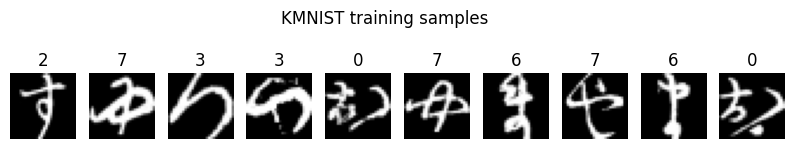

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 468,586 (1.79 MB)

 Trainable params: 468,202 (1.79 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.7715 - loss: 0.8092 - val_accuracy: 0.8435 - val_loss: 0.5454
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9555 - loss: 0.1929 - val_accuracy: 0.9465 - val_loss: 0.2376
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9691 - loss: 0.1450 - val_accuracy: 0.9498 - val_loss: 0.2285
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9761 - loss: 0.1318 - val_accuracy: 0.9592 - val_loss: 0.2127
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9797 - loss: 0.1182 - val_accuracy: 0.9565 - val_loss: 0.2415
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9820 - loss: 0.1151 - val_accuracy: 0.9658 - val_loss: 0.2035
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9822 - loss: 0.1155 - val_accuracy: 0.9608 - val_loss: 0.2195
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9857 - loss: 0.1087 - val_acc

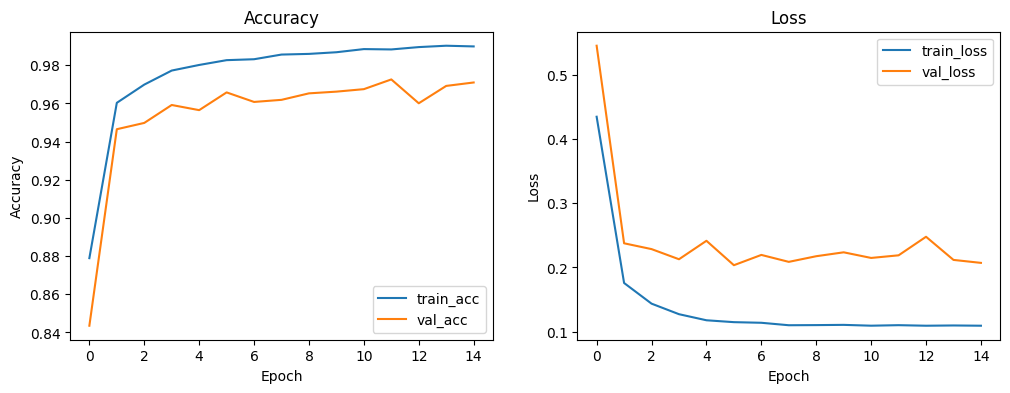

Test Loss: 0.2071 | Test Accuracy: 0.9710

Classification report:
              precision    recall  f1-score   support

           o       0.97      0.97      0.97      1000
          ki       0.98      0.97      0.97      1000
          su       0.94      0.96      0.95      1000
         tsu       0.98      0.98      0.98      1000
          na       0.97      0.94      0.96      1000
          ha       0.98      0.95      0.96      1000
          ma       0.96      0.98      0.97      1000
          ya       0.96      0.98      0.97      1000
          re       0.98      0.98      0.98      1000
          wo       0.98      0.98      0.98      1000

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



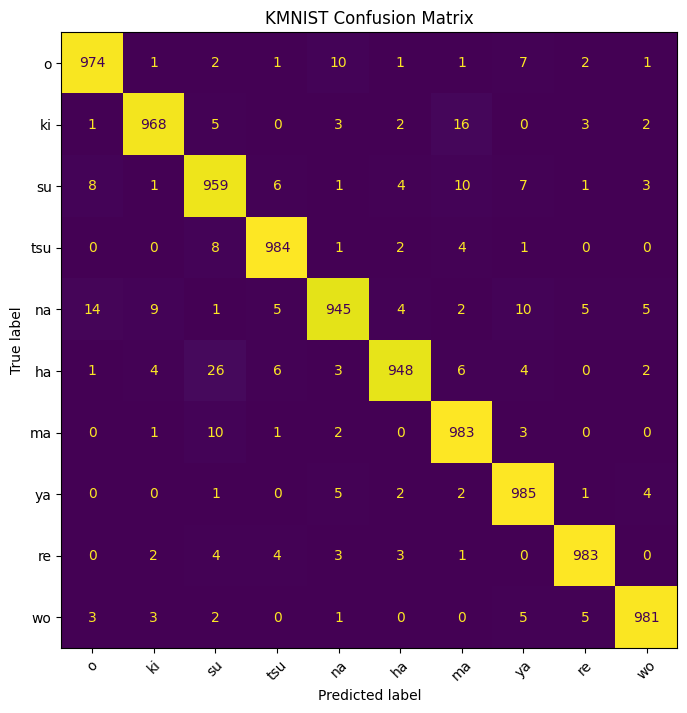

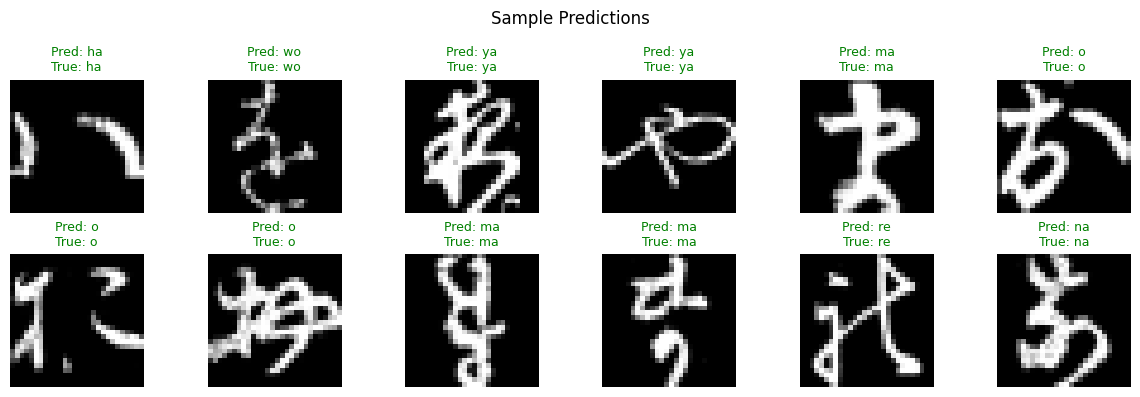

In [ ]:
# %% [markdown]
# # CNN on KMNIST (Kuzushiji-MNIST) with Keras (Sequential API)
# - Load + preprocess dataset (TFDS)
# - Define hyperparameters & optimizer
# - Build a compact CNN
# - Train with callbacks
# - Visualize loss/accuracy curves
# - Evaluate & show confusion matrix + sample predictions

# %% [code]
!pip -q install tensorflow-datasets

# %% [code]
import os
import random
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# (Optional) Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(tf.__version__, tfds.__version__)

# %% [markdown]
# ## 1) Load & prepare KMNIST

# %% [code]
# Load KMNIST (images: 28x28 grayscale, labels: 10 classes)
(ds_train, ds_test), ds_info = tfds.load(
    "kmnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = ds_info.features["label"].num_classes
INPUT_SHAPE = (28, 28, 1)
print("Classes:", NUM_CLASSES, "| Input shape:", INPUT_SHAPE)

# Label names (0..9)
label_names = [str(i) for i in range(NUM_CLASSES)]
if "label" in ds_info.features and hasattr(ds_info.features["label"], "names"):
    label_names = ds_info.features["label"].names
print("Label names:", label_names)

# %% [code]
# Preprocessing: cast to float32, scale to [0,1], add channel dim
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, -1)  # (28,28,1)
    return image, label

BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

ds_train_prep = (ds_train
                 .map(preprocess, num_parallel_calls=AUTOTUNE)
                 .shuffle(10_000, seed=SEED)
                 .batch(BATCH_SIZE)
                 .prefetch(AUTOTUNE))

ds_test_prep = (ds_test
                .map(preprocess, num_parallel_calls=AUTOTUNE)
                .batch(BATCH_SIZE)
                .prefetch(AUTOTUNE))

# Peek a few samples
sample_images, sample_labels = next(iter(ds_train_prep))
plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(sample_images[i].numpy().squeeze(), cmap="gray")
    plt.title(int(sample_labels[i]))
    plt.axis("off")
plt.suptitle("KMNIST training samples")
plt.show()

# %% [markdown]
# ## 2) Define hyperparameters & optimizer

# %% [code]
HP = {
    "epochs": 15,
    "batch_size": BATCH_SIZE,
    "learning_rate": 1e-3,
    "optimizer": "adam",     # "adam" or "sgd"
    "momentum": 0.9,         # used if optimizer="sgd"
    "dropout": 0.3,
    "l2": 1e-4
}
HP

# %% [markdown]
# ## 3) Build the CNN (Sequential API)

# %% [code]
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, SGD

def make_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, hp=HP):
    l2 = regularizers.l2(hp["l2"])
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), padding="same", activation="relu", kernel_regularizer=l2, input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3,3), padding="same", activation="relu", kernel_regularizer=l2),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(hp["dropout"]),

        # Block 2
        Conv2D(64, (3,3), padding="same", activation="relu", kernel_regularizer=l2),
        BatchNormalization(),
        Conv2D(64, (3,3), padding="same", activation="relu", kernel_regularizer=l2),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(hp["dropout"]),

        Flatten(),
        Dense(128, activation="relu", kernel_regularizer=l2),
        Dropout(hp["dropout"]),
        Dense(num_classes, activation="softmax")
    ])

    # Optimizer
    if hp["optimizer"].lower() == "sgd":
        opt = SGD(learning_rate=hp["learning_rate"], momentum=hp["momentum"], nesterov=True)
    else:
        opt = Adam(learning_rate=hp["learning_rate"])

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = make_model()
model.summary()

# %% [markdown]
# ## 4) Train (with callbacks)

# %% [code]
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

callbacks = [
    ReduceLROnPlateau(monitor="val_accuracy", factor=0.5, patience=2, verbose=1, min_lr=1e-5),
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    ds_train_prep,
    validation_data=ds_test_prep,   # KMNIST has no separate val; we validate on test during training for simplicity.
    epochs=HP["epochs"]
)

# %% [markdown]
# ## 5) Visualize training history

# %% [code]
def plot_history(h):
    plt.figure(figsize=(12,4))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(h.history["accuracy"], label="train_acc")
    plt.plot(h.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(h.history["loss"], label="train_loss")
    plt.plot(h.history["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()
    plt.show()

plot_history(history)

# %% [markdown]
# ## 6) Evaluate on test set & confusion matrix

# %% [code]
# Evaluate
test_loss, test_acc = model.evaluate(ds_test_prep, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Collect predictions & true labels
y_true = []
y_pred = []
for batch_x, batch_y in ds_test_prep:
    preds = model.predict(batch_x, verbose=0)
    y_true.extend(batch_y.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=[str(n) for n in label_names]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("KMNIST Confusion Matrix")
plt.show()

# %% [markdown]
# ## 7) Visualize a few predictions

# %% [code]
def show_predictions(ds, count=12):
    imgs, labs = next(iter(ds))
    preds = model.predict(imgs, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    plt.figure(figsize=(12, 4))
    for i in range(count):
        plt.subplot(2, count//2, i+1)
        plt.imshow(imgs[i].numpy().squeeze(), cmap="gray")
        title = f"Pred: {label_names[pred_labels[i]]}\nTrue: {label_names[int(labs[i])]}"
        c = "green" if pred_labels[i] == int(labs[i]) else "red"
        plt.title(title, color=c, fontsize=9)
        plt.axis("off")
    plt.suptitle("Sample Predictions")
    plt.tight_layout()
    plt.show()

show_predictions(ds_test_prep, count=12)

# %% [markdown]
# ### Tips
# - To switch optimizer to SGD: set `HP["optimizer"] = "sgd"`.
# - Tweak `HP["learning_rate"]`, `HP["dropout"]`, or add more layers if underfitting.
# - For a proper validation split, create `ds_train/val` via `tfds.Split.TRAIN.subsplit`.


# CNN for Colour Images

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 21ms/step - accuracy: 0.3545 - loss: 1.8434 - val_accuracy: 0.5382 - val_loss: 1.2949 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.5533 - loss: 1.2404 - val_accuracy: 0.6384 - val_loss: 1.0079 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6358 - loss: 1.0342 - val_accuracy: 0.6426 - val_loss: 1.0254 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.6751 - loss: 0.9273 - val_accuracy: 0.6794 - val_loss: 0.9080 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.6961 - loss: 0.8669 - val_accuracy: 0.7370 - val_loss: 0.7834 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7146 - loss: 0.8137 - val_accuracy: 0.7320 - val_loss: 0.8045 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.7345 - l

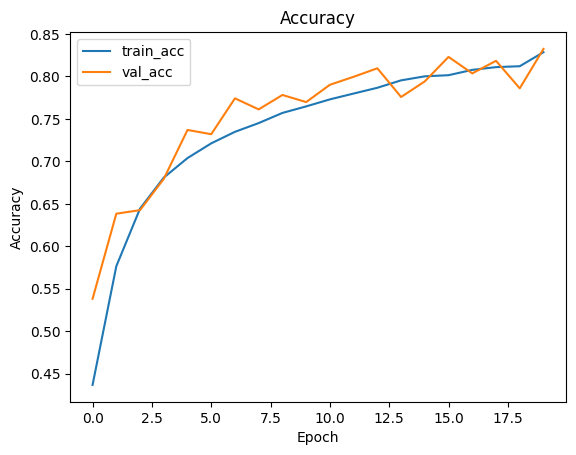

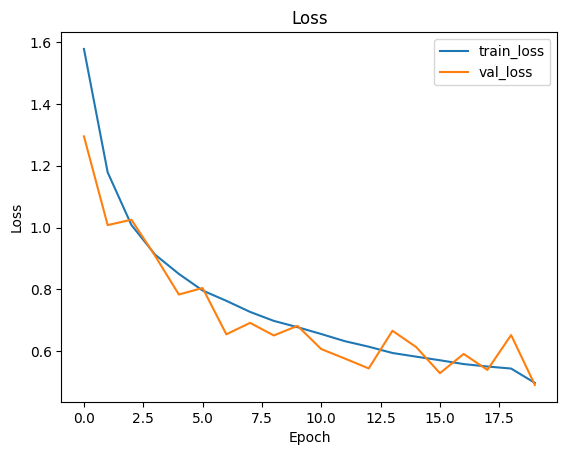

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step


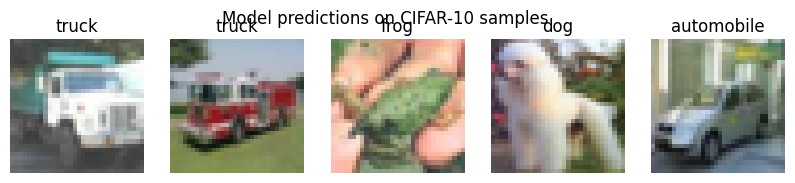

In [ ]:
# CNN for Color Images (TensorFlow/Keras, CIFAR-10)
# -------------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# 1) Load CIFAR-10 (colour images, 32x32x3)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# 2) Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3) Data augmentation pipeline
data_augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

# 4) Build the CNN
def make_model(num_classes=10):
    inputs = layers.Input(shape=(32,32,3))
    x = data_augment(inputs)

    # Block 1
    x = layers.Conv2D(32, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # Classifier head
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="cifar10_cnn")
    return model

model = make_model(10)
model.summary()

# 5) Compile (Adam). Try SGD to compare:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
# optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 6) Train
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
]
history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,            # try 3 first, then 20–30
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

# 7) Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# 8) Plot training curves
plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss")
plt.show()

# 9) Predict a few test images
idx = np.random.choice(len(x_test), size=5, replace=False)
imgs = x_test[idx]
preds = model.predict(imgs)
pred_labels = preds.argmax(axis=1)

# Show predictions
plt.figure(figsize=(10,2))
for i, img in enumerate(imgs):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(class_names[pred_labels[i]])
    plt.axis("off")
plt.suptitle("Model predictions on CIFAR-10 samples")
plt.show()


# Holt-Winters (Triple Exponential Smoothing) on diabetes.csv

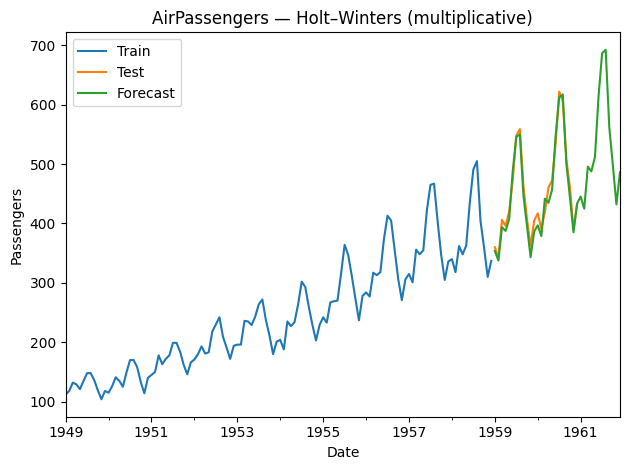

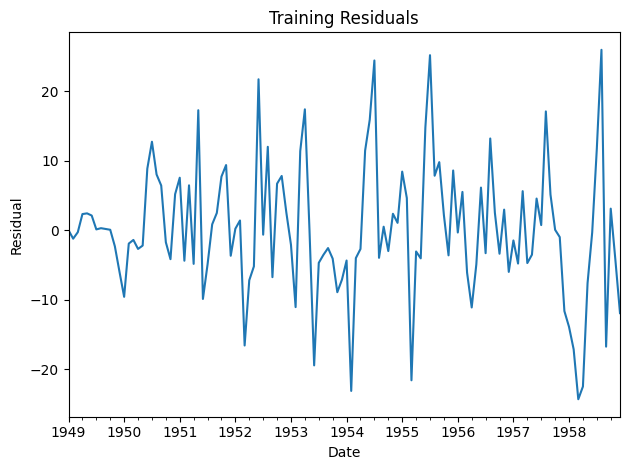

------ SUMMARY ------
Rows: 144 | Train: 120 | Test: 24
Model: ExponentialSmoothing(trend='mul', seasonal='mul', seasonal_periods=12)
Test MAPE: 2.81%
Test RMSE: 13.877
Next 12-month forecast head:
1961-01-01    445.33
1961-02-01    424.87
1961-03-01    495.67
1961-04-01    487.71
1961-05-01    512.30
1961-06-01    614.01
1961-07-01    686.75
1961-08-01    692.43
1961-09-01    562.29
1961-10-01    497.82
1961-11-01    432.09
1961-12-01    486.32
Freq: MS, dtype: float64


In [ ]:
# Holt–Winters (Triple Exponential Smoothing) for AirPassengers.csv
# -----------------------------------------------------------------
# pip install statsmodels pandas matplotlib numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# === 1) Load and parse the AirPassengers CSV ===
CSV_PATH = Path("/content/AirPassengers.csv")  # change if running locally

df = pd.read_csv(CSV_PATH)

# Find the date and value columns robustly
date_col = None
for c in df.columns:
    if c.lower() in ("month", "date", "time", "ds"):
        date_col = c
        break
if date_col is None:
    raise ValueError("Could not find a date column (expected 'Month' / 'Date').")

value_col = None
for c in df.columns:
    if c.lower() in ("passengers", "#passengers", "airpassengers", "value", "y"):
        value_col = c
        break
if value_col is None:
    # fall back to the second column if obvious
    non_date = [c for c in df.columns if c != date_col]
    if not non_date:
        raise ValueError("Could not find passengers/value column.")
    value_col = non_date[0]

# Parse to proper monthly DateTime index
ts = pd.to_datetime(df[date_col], errors="raise")
# Force month-start frequency
idx = pd.PeriodIndex(ts.dt.to_period("M")).to_timestamp(how="start")
y = pd.Series(df[value_col].astype(float).values, index=idx, name="Passengers").sort_index()

# Optional: ensure monthly continuity (fill if any month missing)
y = y.asfreq("MS")

# === 2) Train/Test split ===
# Common choice: keep last 24 months for testing
test_horizon = 24 if len(y) > 36 else max(6, len(y)//5)
y_train, y_test = y.iloc[:-test_horizon], y.iloc[-test_horizon:]

# === 3) Fit Holt–Winters (multiplicative trend & seasonality, period=12) ===
# AirPassengers shows multiplicative effects; use 'mul'.
model = ExponentialSmoothing(
    y_train,
    trend="mul",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated",
)
fit = model.fit(optimized=True, use_brute=True)
# (Optional) Try Box–Cox stabilization:
# fit = model.fit(optimized=True, use_brute=True, use_boxcox='log')

# === 4) Forecast ===
steps = len(y_test) + 12  # predict test window + 12 months ahead
forecast = fit.forecast(steps)

# === 5) Metrics (MAPE & RMSE on test window) ===
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

align = forecast.iloc[:len(y_test)].reindex(y_test.index)
test_mape = mape(y_test, align)
test_rmse = rmse(y_test, align)

# === 6) Plot: train/test/forecast ===
plt.figure()
y_train.plot(label="Train")
y_test.plot(label="Test")
forecast.plot(label="Forecast")
plt.title("AirPassengers — Holt–Winters (multiplicative)")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.tight_layout()
plt.show()

# === 7) Plot: residuals on train ===
residuals = y_train - fit.fittedvalues.reindex(y_train.index)
plt.figure()
residuals.plot()
plt.title("Training Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

# === 8) Summary ===
print("------ SUMMARY ------")
print(f"Rows: {len(y)} | Train: {len(y_train)} | Test: {len(y_test)}")
print("Model: ExponentialSmoothing(trend='mul', seasonal='mul', seasonal_periods=12)")
print(f"Test MAPE: {test_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.3f}")
print(f"Next 12-month forecast head:\n{forecast.iloc[len(y_test):len(y_test)+12].round(2)}")


# RNN (LSTM) for Time-Series Prediction — AirPassengers

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.4145
Epoch 2/200


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2495 
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1023
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1283
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0915
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1145
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1095
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0993
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0906
Epoch 10/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0894
Epoch 11/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0927 
Epoch 12/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0890 
Epoch 13/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0871 
Epoch 14/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0918 
Epoch 15/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0916 
Epoch 16/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0801 
Epoch 17/200
5/5 ━━━━━━━━━━━━

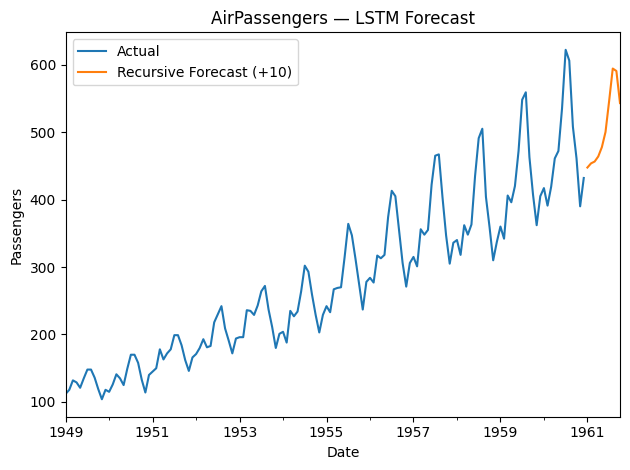

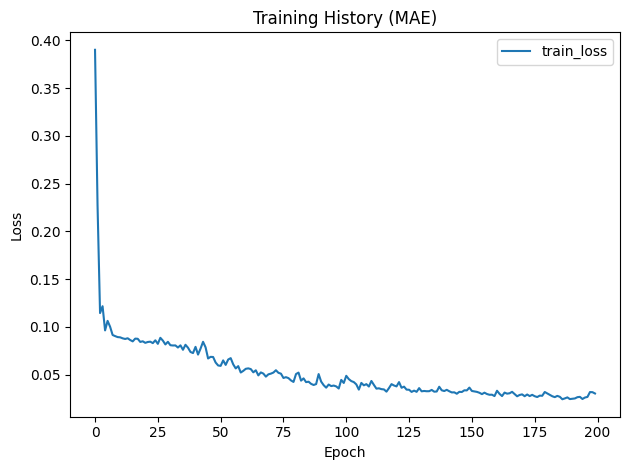

Done. Model followed PPT steps: windowing=30, scaling=[0,1], LSTM+EarlyStopping, recursive forecast=10.


In [ ]:
# RNN (LSTM) for Time-Series Prediction — AirPassengers
# -----------------------------------------------------
# Follows the PPT steps:
# 1) Windowing: past 30 -> predict next 1
# 2) Scaling: Min-Max to [0,1]
# 3) LSTM model
# 4) EarlyStopping on val_loss
# 5) Recursive forecast: predict 10 future months

# pip install pandas numpy matplotlib scikit-learn tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# === 0) Config ===
CSV_PATH = Path("/content/AirPassengers.csv")
TARGET_COL_CANDIDATES = ["Passengers", "passengers", "value", "y"]

WINDOW_SIZE = 30
FORECAST_STEPS = 10           # recursive forecast length
TEST_SIZE = 24                # last N months as test
VAL_SIZE = 12                 # last N of the train as validation

# === 1) Load & prepare monthly series ===
df = pd.read_csv(CSV_PATH)

# robustly find date & value columns
date_col = None
for c in df.columns:
    if c.lower() in ("month", "date", "time", "ds"):
        date_col = c
        break
if date_col is None:
    raise ValueError("No date column found (expected 'Month'/'Date'/'Time'/'ds').")

value_col = None
for c in TARGET_COL_CANDIDATES:
    if c in df.columns:
        value_col = c
        break
if value_col is None:
    # fallback: second column if there are exactly two
    non_date = [c for c in df.columns if c != date_col]
    if not non_date:
        raise ValueError("No value column found.")
    value_col = non_date[0]

# monthly index
ts = pd.to_datetime(df[date_col], errors="raise")
idx = pd.PeriodIndex(ts.dt.to_period("M")).to_timestamp(how="start")
y = pd.Series(df[value_col].astype(float).values, index=idx, name="Passengers").sort_index()
y = y.asfreq("MS")  # ensure monthly-start frequency

# === 2) Train/Val/Test split (chronological) ===
# Keep last TEST_SIZE for test; from the remaining, last VAL_SIZE for validation
y_train_full = y.iloc[:-TEST_SIZE] if TEST_SIZE < len(y) else y.copy()
y_test = y.iloc[-TEST_SIZE:] if TEST_SIZE < len(y) else pd.Series([], dtype=float)

y_train = y_train_full.iloc[:-VAL_SIZE] if VAL_SIZE < len(y_train_full) else y_train_full.copy()
y_val = y_train_full.iloc[-VAL_SIZE:] if VAL_SIZE < len(y_train_full) else pd.Series([], dtype=float)

# === 3) Scale to [0,1] ===
scaler = MinMaxScaler(feature_range=(0, 1))
y_train_vals = y_train.values.reshape(-1, 1)
scaler.fit(y_train_vals)

y_train_s = scaler.transform(y_train_vals).flatten()
y_val_s = scaler.transform(y_val.values.reshape(-1, 1)).flatten() if len(y_val) else np.array([])
y_test_s = scaler.transform(y_test.values.reshape(-1, 1)).flatten() if len(y_test) else np.array([])

# === 4) Windowing function: past 30 -> next 1 ===
def make_windows(series_1d, window):
    X, y_next = [], []
    for i in range(len(series_1d) - window):
        X.append(series_1d[i:i+window])
        y_next.append(series_1d[i+window])
    X = np.array(X)
    y_next = np.array(y_next)
    return X[..., None], y_next  # add feature dim

X_train, y_train_target = make_windows(y_train_s, WINDOW_SIZE)
X_val, y_val_target = (make_windows(y_val_s, WINDOW_SIZE) if len(y_val_s) > WINDOW_SIZE else (None, None))

# === 5) Build LSTM model ===
model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(WINDOW_SIZE, 1)),
    Dense(32, activation="relu"),
    Dense(1)  # next value (scaled)
])

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mae")
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

# If val set too small, train without validation
if X_val is not None:
    history = model.fit(
        X_train, y_train_target,
        validation_data=(X_val, y_val_target),
        epochs=200,
        batch_size=16,
        callbacks=[es],
        verbose=1
    )
else:
    history = model.fit(
        X_train, y_train_target,
        epochs=200,
        batch_size=16,
        callbacks=[es],
        verbose=1
    )

# === 6) In-sample predictions for train/val (optional) ===
train_pred_s = model.predict(X_train, verbose=0).flatten()
if X_val is not None:
    val_pred_s = model.predict(X_val, verbose=0).flatten()
else:
    val_pred_s = np.array([])

# Align predictions back to dates
def to_series(pred_scaled, base_index, window):
    # aligns predictions to the timestamp of the target step
    idx = base_index[window:]
    vals = scaler.inverse_transform(pred_scaled.reshape(-1,1)).flatten()
    return pd.Series(vals, index=idx)

train_pred = to_series(train_pred_s, y_train.index, WINDOW_SIZE)
val_pred = to_series(val_pred_s, y_val.index, WINDOW_SIZE) if len(val_pred_s) else pd.Series(dtype=float)

# === 7) Test one-step-ahead predictions (rolled) ===
test_pred = pd.Series(dtype=float)
if len(y_test_s) > WINDOW_SIZE:
    # build windows that start from end of train+val
    all_train_val_s = np.concatenate([y_train_s, y_val_s]) if len(y_val_s) else y_train_s
    start_context = all_train_val_s[-WINDOW_SIZE:]  # last window before test
    preds = []
    for i in range(len(y_test_s)):
        # one-step-ahead with true history (teacher forcing style window)
        if i == 0:
            window_arr = start_context.copy()
        else:
            # shift in the TRUE test value for next one-step-ahead window
            window_arr = np.concatenate([window_arr[1:], [y_test_s[i-1]]])
        yhat = model.predict(window_arr.reshape(1, WINDOW_SIZE, 1), verbose=0)[0,0]
        preds.append(yhat)
    test_pred_s = np.array(preds)
    test_pred = pd.Series(
        scaler.inverse_transform(test_pred_s.reshape(-1,1)).flatten(),
        index=y_test.index
    )

# === 8) Recursive multi-step forecast (next 10 months) ===
# start from the last available true values (train+val+test)
series_all_s = np.concatenate([y_train_s, y_val_s, y_test_s])
context = series_all_s[-WINDOW_SIZE:] if len(series_all_s) >= WINDOW_SIZE else series_all_s
future_scaled = []
for _ in range(FORECAST_STEPS):
    yhat = model.predict(context.reshape(1, WINDOW_SIZE, 1), verbose=0)[0,0]
    future_scaled.append(yhat)
    context = np.concatenate([context[1:], [yhat]]) if len(context) >= WINDOW_SIZE else np.append(context, yhat)
future_vals = scaler.inverse_transform(np.array(future_scaled).reshape(-1,1)).flatten()

last_date = y.index[-1]
future_index = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=FORECAST_STEPS, freq="MS")
future_series = pd.Series(future_vals, index=future_index, name="Forecast")

# === 9) Plots (single-axes each, as required) ===
# Plot 1: full series + test preds + future forecast
plt.figure()
y.plot(label="Actual")
if len(test_pred) > 0:
    test_pred.plot(label="Test Pred (1-step ahead)")
future_series.plot(label=f"Recursive Forecast (+{FORECAST_STEPS})")
plt.title("AirPassengers — LSTM Forecast")
plt.xlabel("Date"); plt.ylabel("Passengers"); plt.legend(); plt.tight_layout(); plt.show()

# Plot 2: training history
if "loss" in history.history:
    plt.figure()
    plt.plot(history.history["loss"], label="train_loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("Training History (MAE)")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()

# === 10) Simple metrics on test (if available) ===
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0)

if len(test_pred) > 0:
    test_mape = mape(y_test.values, test_pred.values)
    print(f"Test MAPE (1-step ahead): {test_mape:.2f}%")

print("Done. Model followed PPT steps: windowing=30, scaling=[0,1], LSTM+EarlyStopping, recursive forecast=10.")


# CA 1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=128,
    verbose=1
)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8170 - loss: 0.5914 - val_accuracy: 0.9830 - val_loss: 0.0619
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9735 - loss: 0.0874 - val_accuracy: 0.9878 - val_loss: 0.0427
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9829 - loss: 0.0554 - val_accuracy: 0.9892 - val_loss: 0.0382
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9867 - loss: 0.0424 - val_accuracy: 0.9900 - val_loss: 0.0375
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0355 - val_accuracy: 0.9917 - val_loss: 0.0328
Test accuracy: 0.9909
